In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
y_train shape: (60000,)
y_test shape: (10000,)


In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [5]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [6]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

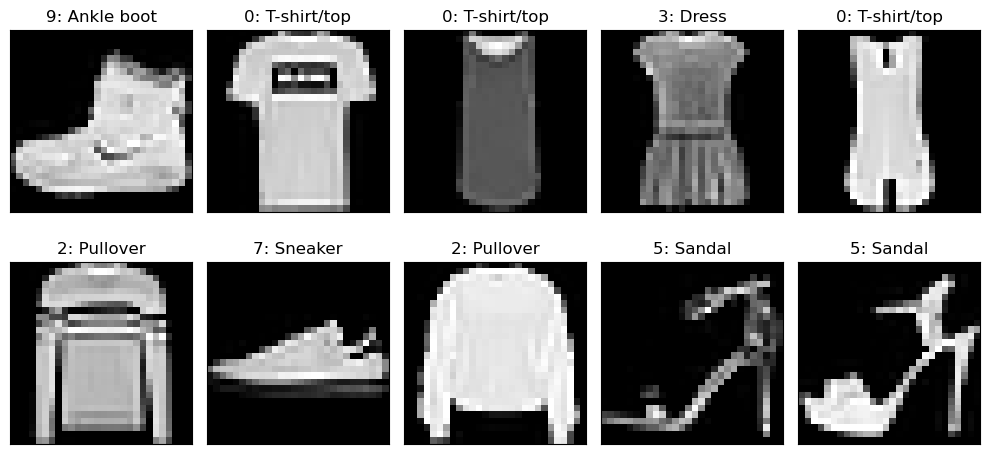

In [7]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(str(y_train[i]) + ": " + class_names[y_train[i]])

plt.tight_layout()
plt.show()

In [8]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


In [9]:
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Input, Dense, Dropout, BatchNormalization
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

input_shape = (28, 28, 1)

input_img = Input(shape=input_shape)

# First convolutional layer
c11 = Conv2D(
    64,
    (5, 5),
    strides=(1, 1),
    activation='relu'
)(input_img)

p12 = MaxPooling2D(pool_size=(2, 2))(c11)

bn13 = BatchNormalization()(p12)


# Second convolutional layer
c14 = Conv2D(
    128,
    (3, 3),
    strides=(1, 1),
    activation='relu'
)(bn13)

p15 = MaxPooling2D(pool_size=(2, 2))(c14)

bn16 = BatchNormalization()(p15)


# Flatten
f17 = Flatten()(bn16)


# Fully connected layers
do18 = Dropout(0.5)(f17)

d19 = Dense(
    units=256,
    activation='relu'
)(do18)

do110 = Dropout(0.2)(d19)

d111 = Dense(
    units=64,
    activation='relu'
)(do110)

do112 = Dropout(0.1)(d111)


# Output layer
output = Dense(
    units=10,
    activation='softmax'
)(do112)


classifier = Model(input_img, output)

classifier.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,842 (3.48 MB)

 Trainable params: 912,458 (3.48 MB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
opt = RMSprop(learning_rate=0.001)

classifier.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_delta=1e-4,
    mode='min',
    verbose=1
)

stop_alg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint_filepath = 'fashion_cnn_model.keras'

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [12]:
hist = classifier.fit(
    x_train,
    y_train,
    batch_size=256,
    epochs=20,
    callbacks=[
        stop_alg,
        reduce_lr,
        model_checkpoint
    ],
    shuffle=True,
    validation_split=0.1
)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.7920 - loss: 0.5980 - val_accuracy: 0.2700 - val_loss: 2.6640 - learning_rate: 0.0010
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.8642 - loss: 0.3699 - val_accuracy: 0.5710 - val_loss: 1.2344 - learning_rate: 0.0010
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.8825 - loss: 0.3163 - val_accuracy: 0.8958 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.8948 - loss: 0.2867 - val_accuracy: 0.8852 - val_loss: 0.3011 - learning_rate: 0.0010
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.9032 - loss: 0.2624 - val_accuracy: 0.9083 - val_loss: 0.2569 - learning_rate: 0.0010
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.9066 - loss: 0.2508 - val_accuracy: 0.9072 - val_loss: 0.2577 - learning_rate: 0.0010
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.9126 - l

In [13]:
classifier.save_weights("fashion_cnn.weights.h5")

In [14]:
classifier.save("fashion_cnn_model.keras")

print("Model saved successfully!")

Model saved successfully!


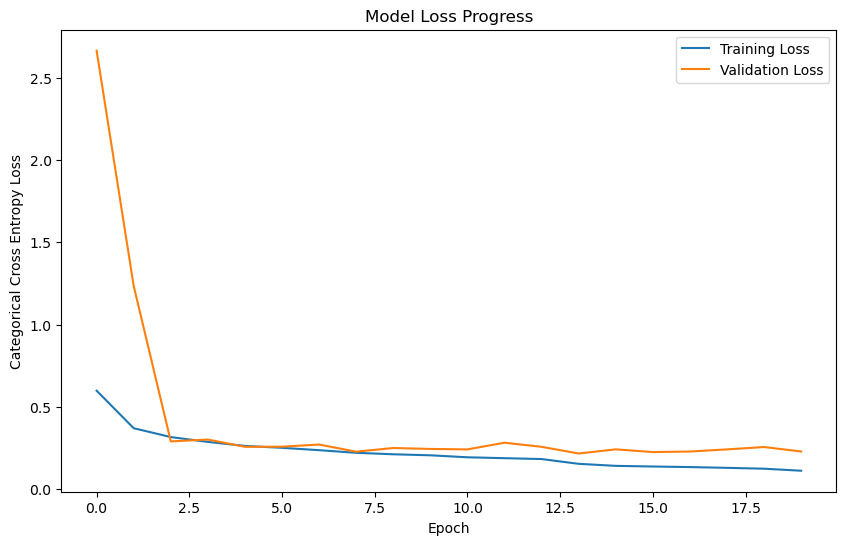

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist.history['loss'],
    label='Training Loss'
)

plt.plot(
    hist.history['val_loss'],
    label='Validation Loss'
)

plt.title('Model Loss Progress')
plt.ylabel('Categorical Cross Entropy Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.show()

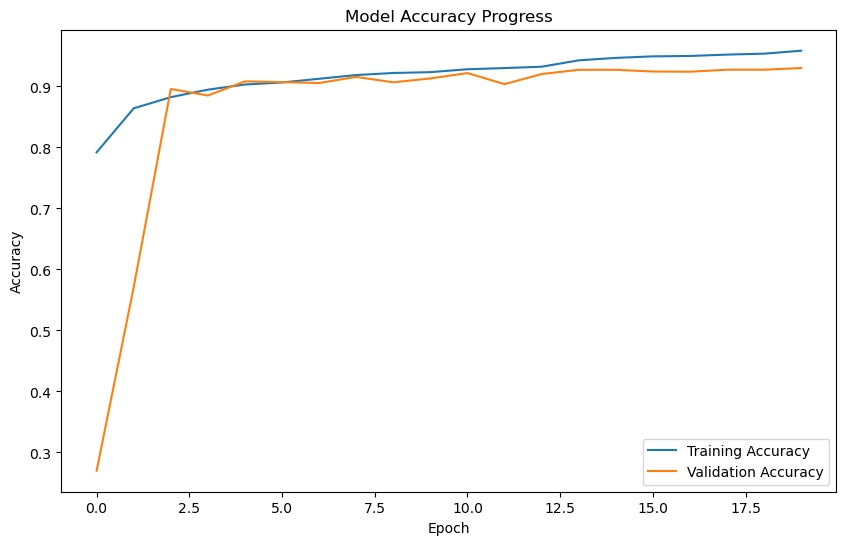

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    hist.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Model Accuracy Progress')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

plt.show()

In [17]:
test_loss, test_acc = classifier.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.9243 - loss: 0.2377
Test Loss: 0.23767973482608795
Test Accuracy: 0.9243000149726868


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import balanced_accuracy_score

y_hat = classifier.predict(x_test)

y_pred = np.argmax(y_hat, axis=1)
y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.88      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.89      0.87      0.88      1000
       Dress       0.93      0.93      0.93      1000
        Coat       0.87      0.89      0.88      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.78      0.76      0.77      1000
     Sneaker       0.97      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.97      0.98      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



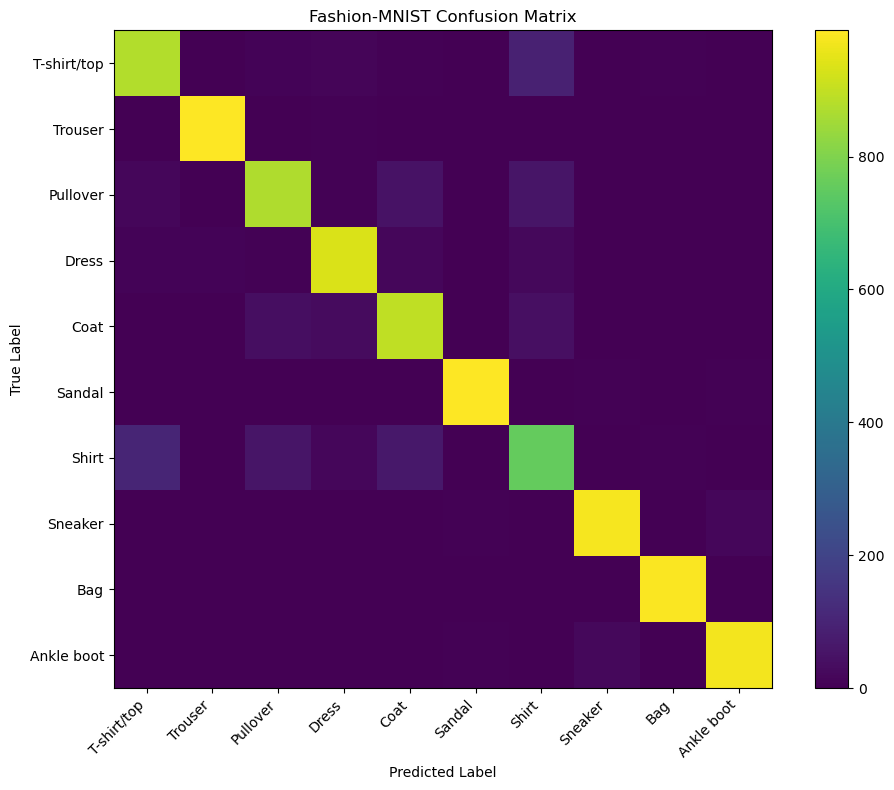

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(10),
    class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Fashion-MNIST Confusion Matrix')

plt.colorbar()

plt.tight_layout()
plt.show()

In [23]:
balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

ber = 1 - balanced_acc

print("Balanced Accuracy:", balanced_acc)
print("BER:", ber)

Balanced Accuracy: 0.9243
BER: 0.07569999999999999


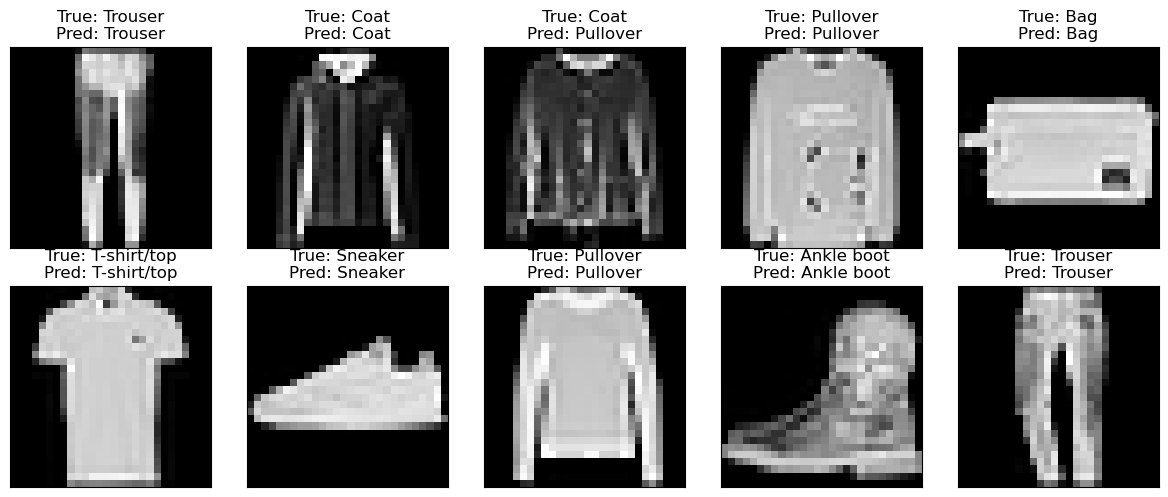

In [24]:
idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]

plt.figure(figsize=(12, 5))

for i, index in enumerate(idx):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[index].squeeze(),
        cmap='gray'
    )

    true_label = y_true[index]
    predicted_label = y_pred[index]

    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}"
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

In [25]:
cnn_layer = classifier.get_layer(
    name=classifier.layers[1].name
)

w = cnn_layer.get_weights()[0]

print("Filter shape:", w.shape)

Filter shape: (5, 5, 1, 64)


In [26]:
from sklearn.preprocessing import MinMaxScaler

wshape = w.shape

scaler = MinMaxScaler()

scaler.fit(w.reshape(-1, 1))

w_scaled = scaler.transform(
    w.reshape(-1, 1)
)

w_scaled = w_scaled.reshape(wshape)

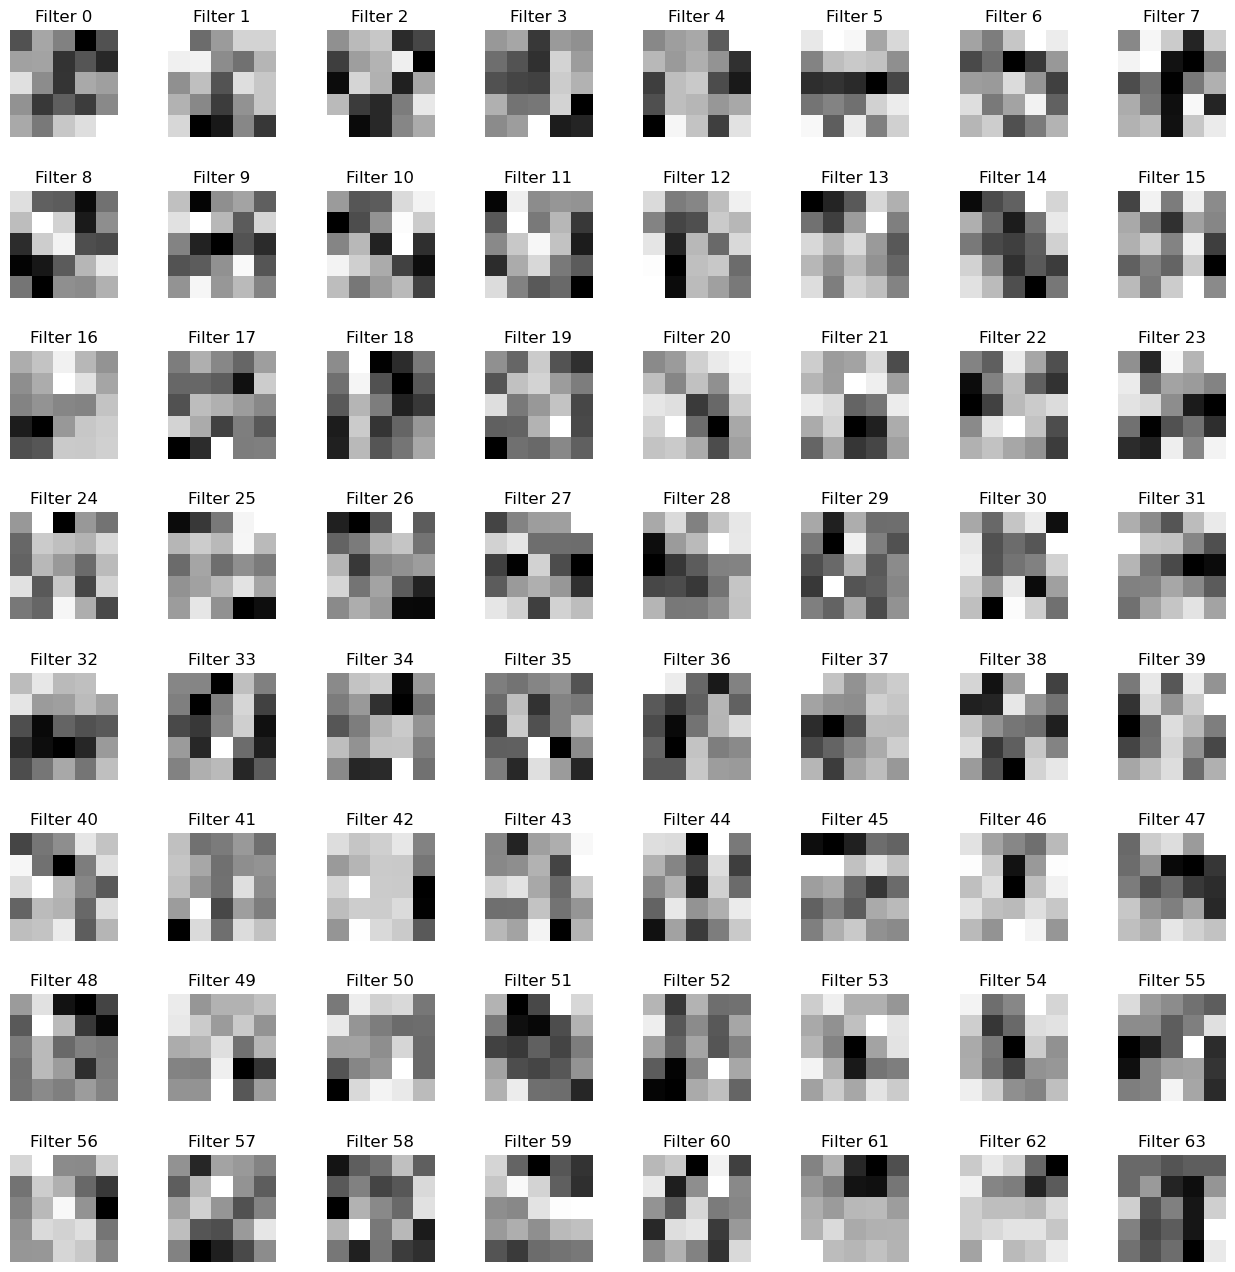

In [27]:
fig, axs = plt.subplots(
    8,
    8,
    figsize=(16, 16)
)

fig.subplots_adjust(
    hspace=0.5,
    wspace=0.2
)

axs = axs.ravel()

for i in range(min(64, w_scaled.shape[-1])):

    # Extract one grayscale filter
    filter_img = w_scaled[:, :, 0, i]

    axs[i].imshow(
        filter_img,
        cmap='gray'
    )

    axs[i].set_title(
        'Filter ' + str(i)
    )

    axs[i].axis('off')

plt.show()

In [30]:
from tensorflow import keras

# Load the complete model
loaded_model = keras.models.load_model("fashion_cnn_model.keras")

print("Model loaded successfully!")
loaded_model.summary()

Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,825,302 (6.96 MB)

 Trainable params: 912,458 (3.48 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 912,460 (3.48 MB)

In [31]:
print("Original model:")
classifier.summary()

print("\nLoaded model:")
loaded_model.summary()

Original model:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,825,302 (6.96 MB)

 Trainable params: 912,458 (3.48 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,825,302 (6.96 MB)

 Trainable params: 912,458 (3.48 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 912,460 (3.48 MB)

In [32]:
predictions = loaded_model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_true[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
First 10 predictions:
[9 2 1 1 6 1 4 6 5 7]

First 10 actual labels:
[9 2 1 1 6 1 4 6 5 7]


In [33]:
loss, accuracy = loaded_model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9243 - loss: 0.2377
Test Loss: 0.23767973482608795
Test Accuracy: 0.9243000149726868
